# Train ResNet34 on PathMNIST

In [1]:

from pathlib import Path
import os
import shutil
import sys

ROOT = Path.cwd().parents[1].resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ.setdefault(
    "PYTHON_JULIAPKG_PROJECT",
    str(Path.home() / "Documents" / "dev" / "MAGENetRunner" / "python_utils"),
)
os.environ.setdefault("PYTHON_JULIAPKG_OFFLINE", "yes")
julia_exe = shutil.which("julia")
if julia_exe is not None:
    os.environ.setdefault("PYTHON_JULIAPKG_EXE", julia_exe)


In [2]:

import torch

from python_utils.medmnist_resnet_baseline import (
    DatasetConfig,
    build_model,
    clean_checkpoints,
    evaluate_loader,
    load_checkpoint,
    plot_training_curves,
    prepare_experiment,
    print_metrics,
    select_best_checkpoint,
    train_model,
)


/home/camilo/Documents/dev/MAGENetRunner/.CondaPkg/env/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [3]:

SEED = 123
TRAIN_BATCH_SIZE = 128
EVAL_BATCH_SIZE = 512
EPOCHS = 30
LR = 1e-4
WEIGHT_DECAY = 1e-4
USE_CLASS_WEIGHTS = True
RESIZE_TO = 224

CONFIG = DatasetConfig(
    dataset_name="PathMNIST",
    train_file=str(ROOT / "datasets_pickle" / "PathMNIST_64_train.jld2"),
    val_file=str(ROOT / "datasets_pickle" / "PathMNIST_64_val.jld2"),
    test_file=str(ROOT / "datasets_pickle" / "PathMNIST_64_test.jld2"),
    num_classes=9,
    batch_size=TRAIN_BATCH_SIZE,
    val_batch_size=EVAL_BATCH_SIZE,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    use_class_weights=USE_CLASS_WEIGHTS,
    seed=SEED,
    resize_to=RESIZE_TO,
    output_dir="PathMNIST/NN_baselines",
    experiment_name="resnet34_PathMNIST",
    backbone_name="resnet34",
    nd=3,
    pretrained_weights="default",
)

CONFIG


DatasetConfig(dataset_name='PathMNIST', train_file='/home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/PathMNIST_64_train.jld2', val_file='/home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/PathMNIST_64_val.jld2', test_file='/home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/PathMNIST_64_test.jld2', num_classes=9, batch_size=128, val_batch_size=512, epochs=30, lr=0.0001, weight_decay=0.0001, use_class_weights=True, seed=123, resize_to=224, output_dir='PathMNIST/NN_baselines', experiment_name='resnet34_PathMNIST', backbone_name='resnet34', nd=3, pretrained_weights='default')

In [4]:

CONTEXT = prepare_experiment(CONFIG)
MODEL = build_model(
    CONFIG.backbone_name,
    CONFIG.num_classes,
    pretrained_weights=CONFIG.pretrained_weights,
).to(CONTEXT.device)
OPTIMIZER = torch.optim.AdamW(
    MODEL.parameters(),
    lr=CONFIG.lr,
    weight_decay=CONFIG.weight_decay,
)


Reading /home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/PathMNIST_64_train.jld2
Reading /home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/PathMNIST_64_val.jld2
Reading /home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/PathMNIST_64_test.jld2
TORCH DEVICE cuda
N CPUS 16
CWD : /home/camilo/Documents/dev/MAGENetRunner/PathMNIST/NN_baselines
Metrics file: /home/camilo/Documents/dev/MAGENetRunner/PathMNIST/NN_baselines/resnet34_PathMNIST/cnn_metrics_resnet.csv
TRAIN DATASET SIZE : 89996
VAL DATASET SIZE : 10004
TEST DATASET SIZE : 7180
normalization mean: [0.7405405640602112, 0.5330104231834412, 0.7058323621749878] | std: [0.14004458487033844, 0.19477929174900055, 0.13842304050922394]
class weights: [1.0676442384719849, 1.051588535308838, 0.9652080535888672, 0.9614033102989197, 1.2490077018737793, 0.8208467960357666, 1.268013596534729, 1.0636693239212036, 0.7760617136955261]


In [5]:

METRICS_DF = train_model(CONTEXT, MODEL, OPTIMIZER)
METRICS_DF.tail()


Epoch [0/30], Train Loss: 2.4211, Train ACC: 0.0630, Train BACC: 0.0623
Epoch [0/30], Val Loss: 2.4268, Val ACC: 0.0667, Val BACC: 0.0669
Checkpoint saved at epoch 1 to /home/camilo/Documents/dev/MAGENetRunner/PathMNIST/NN_baselines/resnet34_PathMNIST/DLmodels_resnet/checkpoints/1.pth
Epoch [1/30], Train Loss: 0.1385, Train ACC: 0.9543, Train BACC: 0.9552
Epoch [1/30], Val Loss: 0.0541, Val ACC: 0.9822, Val BACC: 0.9825
Checkpoint saved at epoch 2 to /home/camilo/Documents/dev/MAGENetRunner/PathMNIST/NN_baselines/resnet34_PathMNIST/DLmodels_resnet/checkpoints/2.pth
Epoch [2/30], Train Loss: 0.0598, Train ACC: 0.9804, Train BACC: 0.9806
Epoch [2/30], Val Loss: 0.0400, Val ACC: 0.9872, Val BACC: 0.9865
Checkpoint saved at epoch 3 to /home/camilo/Documents/dev/MAGENetRunner/PathMNIST/NN_baselines/resnet34_PathMNIST/DLmodels_resnet/checkpoints/3.pth
Epoch [3/30], Train Loss: 0.0483, Train ACC: 0.9840, Train BACC: 0.9842
Epoch [3/30], Val Loss: 0.0281, Val ACC: 0.9905, Val BACC: 0.9909
Chec

,epoch,loss,val_loss,accuracy,val_accuracy,balanced_accuracy,val_balanced_accuracy
26,26,0.010409,0.013407,0.996544,0.995702,0.996580,0.995676
27,27,0.009441,0.016291,0.996889,0.996501,0.996930,0.996339
28,28,0.011593,0.018086,0.996367,0.994902,0.996427,0.995016
29,29,0.010742,0.019138,0.996478,0.995502,0.996495,0.995651
30,30,0.008756,0.012382,0.997389,0.996501,0.997400,0.996579


In [6]:

BEST_VAL_ACC_CKPT, METRICS_DF = select_best_checkpoint(CONTEXT, "val_accuracy")
BEST_VAL_ACC_MODEL = build_model(
    CONFIG.backbone_name,
    CONFIG.num_classes,
    pretrained_weights=CONFIG.pretrained_weights,
).to(CONTEXT.device)
load_checkpoint(BEST_VAL_ACC_MODEL, BEST_VAL_ACC_CKPT, CONTEXT.device)
VAL_ACC_METRICS, _, _, _ = evaluate_loader(
    BEST_VAL_ACC_MODEL,
    CONTEXT.val_dataloader,
    CONTEXT.device,
    CONFIG.num_classes,
)
TEST_ACC_METRICS, _, _, _ = evaluate_loader(
    BEST_VAL_ACC_MODEL,
    CONTEXT.test_dataloader,
    CONTEXT.device,
    CONFIG.num_classes,
)
print_metrics("Best Val-ACC checkpoint | Validation", VAL_ACC_METRICS)
print_metrics("Best Val-ACC checkpoint | Test", TEST_ACC_METRICS)


Best val_accuracy: epoch 25
Checkpoint to read: /home/camilo/Documents/dev/MAGENetRunner/PathMNIST/NN_baselines/resnet34_PathMNIST/DLmodels_resnet/checkpoints/25.pth
Loaded checkpoint /home/camilo/Documents/dev/MAGENetRunner/PathMNIST/NN_baselines/resnet34_PathMNIST/DLmodels_resnet/checkpoints/25.pth
Best Val-ACC checkpoint | Validation Accuracy: 0.997
Best Val-ACC checkpoint | Validation Balanced Accuracy: 0.997
Best Val-ACC checkpoint | Validation AUC: 1.000
Best Val-ACC checkpoint | Test Accuracy: 0.928
Best Val-ACC checkpoint | Test Balanced Accuracy: 0.922
Best Val-ACC checkpoint | Test AUC: 0.996


In [7]:

BEST_VAL_BACC_CKPT, METRICS_DF = select_best_checkpoint(CONTEXT, "val_balanced_accuracy")
BEST_VAL_BACC_MODEL = build_model(
    CONFIG.backbone_name,
    CONFIG.num_classes,
    pretrained_weights=CONFIG.pretrained_weights,
).to(CONTEXT.device)
load_checkpoint(BEST_VAL_BACC_MODEL, BEST_VAL_BACC_CKPT, CONTEXT.device)
VAL_BACC_METRICS, _, _, _ = evaluate_loader(
    BEST_VAL_BACC_MODEL,
    CONTEXT.val_dataloader,
    CONTEXT.device,
    CONFIG.num_classes,
)
TEST_BACC_METRICS, _, _, _ = evaluate_loader(
    BEST_VAL_BACC_MODEL,
    CONTEXT.test_dataloader,
    CONTEXT.device,
    CONFIG.num_classes,
)
print_metrics("Best Val-BACC checkpoint | Validation", VAL_BACC_METRICS)
print_metrics("Best Val-BACC checkpoint | Test", TEST_BACC_METRICS)


Best val_balanced_accuracy: epoch 30
Checkpoint to read: /home/camilo/Documents/dev/MAGENetRunner/PathMNIST/NN_baselines/resnet34_PathMNIST/DLmodels_resnet/checkpoints/30.pth
Loaded checkpoint /home/camilo/Documents/dev/MAGENetRunner/PathMNIST/NN_baselines/resnet34_PathMNIST/DLmodels_resnet/checkpoints/30.pth
Best Val-BACC checkpoint | Validation Accuracy: 0.997
Best Val-BACC checkpoint | Validation Balanced Accuracy: 0.997
Best Val-BACC checkpoint | Validation AUC: 1.000
Best Val-BACC checkpoint | Test Accuracy: 0.941
Best Val-BACC checkpoint | Test Balanced Accuracy: 0.918
Best Val-BACC checkpoint | Test AUC: 0.995


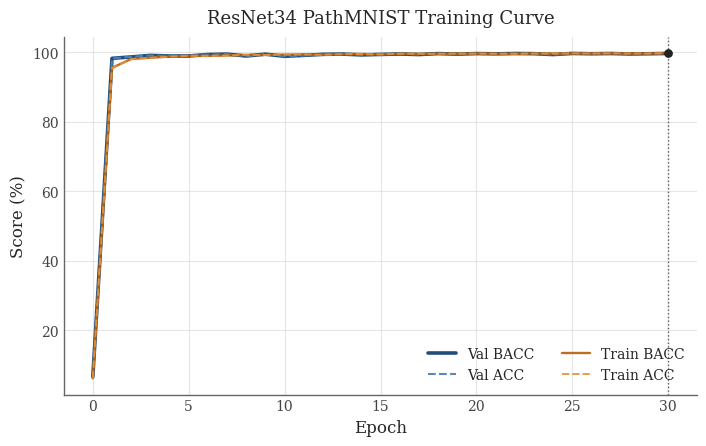

Saved plot to /home/camilo/Documents/dev/MAGENetRunner/PathMNIST/NN_baselines/resnet34_PathMNIST/training_curve_resnet34.png
Deleting: /home/camilo/Documents/dev/MAGENetRunner/PathMNIST/NN_baselines/resnet34_PathMNIST/DLmodels_resnet/checkpoints/11.pth
Deleting: /home/camilo/Documents/dev/MAGENetRunner/PathMNIST/NN_baselines/resnet34_PathMNIST/DLmodels_resnet/checkpoints/5.pth
Deleting: /home/camilo/Documents/dev/MAGENetRunner/PathMNIST/NN_baselines/resnet34_PathMNIST/DLmodels_resnet/checkpoints/17.pth
Deleting: /home/camilo/Documents/dev/MAGENetRunner/PathMNIST/NN_baselines/resnet34_PathMNIST/DLmodels_resnet/checkpoints/19.pth
Deleting: /home/camilo/Documents/dev/MAGENetRunner/PathMNIST/NN_baselines/resnet34_PathMNIST/DLmodels_resnet/checkpoints/3.pth
Deleting: /home/camilo/Documents/dev/MAGENetRunner/PathMNIST/NN_baselines/resnet34_PathMNIST/DLmodels_resnet/checkpoints/6.pth
Deleting: /home/camilo/Documents/dev/MAGENetRunner/PathMNIST/NN_baselines/resnet34_PathMNIST/DLmodels_resnet/c

In [8]:

PLOT_PATH = CONTEXT.folder / "training_curve_resnet34.png"
plot_training_curves(
    METRICS_DF,
    title="ResNet34 PathMNIST Training Curve",
    output_path=PLOT_PATH,
)
clean_checkpoints(CONTEXT.checkpoint_dir, {BEST_VAL_ACC_CKPT, BEST_VAL_BACC_CKPT})
